In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Завдання 1: Завантаження та Data Cleaning
Зчитати обраний багатовимірний датасет (який має категоріальні, цілі та дійсні атрибути, а також пропущені значення). Здійснити очищення даних (Data Cleaning).

In [23]:
auto_cols = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
             'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
             'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
             'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
             'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

df = pd.read_csv('data/automobile/imports-85.data', names=auto_cols, na_values='?')

display(df.head())
df.info()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [24]:

print("Пропуски ДО очищення")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

df.dropna(subset=['price'], inplace=True)

cols_to_fill_mean = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in cols_to_fill_mean:
    df[col] = pd.to_numeric(df[col])
    df[col] = df[col].fillna(df[col].mean())


df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print("\nПропуски ПІСЛЯ очищення")
print("Залишилось пропусків:", df.isnull().sum().max())

Пропуски ДО очищення
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

Пропуски ПІСЛЯ очищення
Залишилось пропусків: 0


## Завдання 2: Графіки залежності
Побудувати графіки залежності одного числового (integer/real) атрибута від іншого (lineplot, scatter тощо).

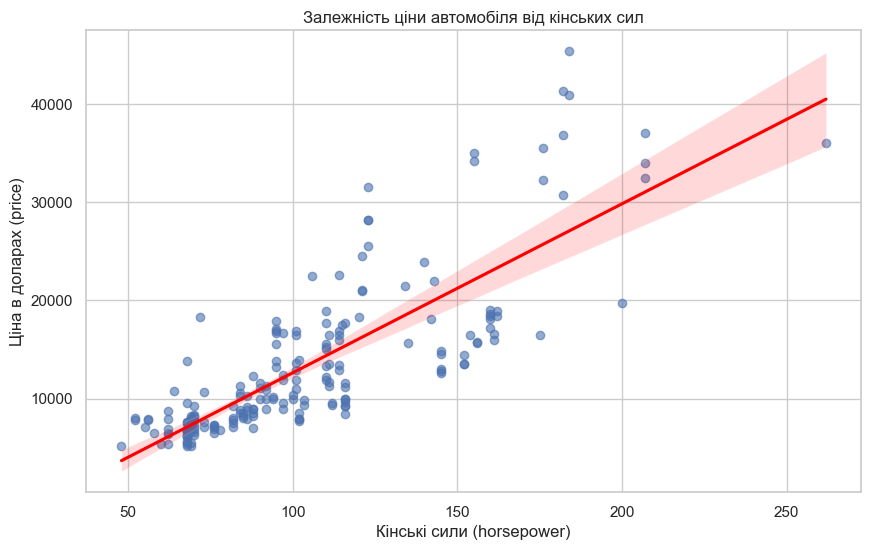

In [25]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='horsepower', y='price', 
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

plt.title("Залежність ціни автомобіля від кінських сил")
plt.xlabel("Кінські сили (horsepower)")
plt.ylabel("Ціна в доларах (price)")

plt.show()

## Завдання 3: Гістограма розподілу
Побудувати гістограму по одному з атрибутів, що буде показувати кількість елементів, які знаходяться у 5 заданих діапазонах.

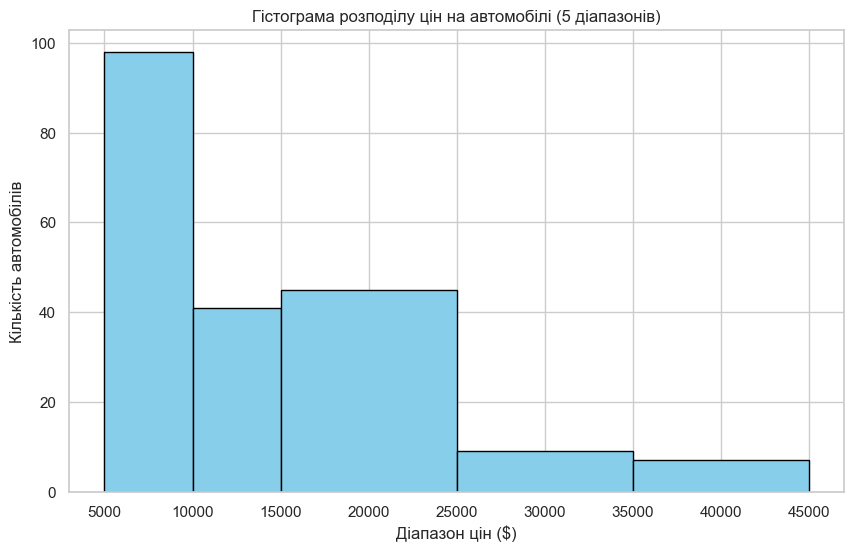

In [26]:
plt.figure(figsize=(10, 6))

my_custom_bins = [5000, 10000, 15000, 25000, 35000, 45000]

plt.hist(df['price'], bins=my_custom_bins, color='skyblue', edgecolor='black')

plt.title("Гістограма розподілу цін на автомобілі (5 діапазонів)")
plt.xlabel("Діапазон цін ($)")
plt.ylabel("Кількість автомобілів")

plt.show()

## Завдання 4: Багатовимірні графіки
Збудувати графіки, використовуючи приклади ефективної візуалізації багатовимірних даних (на основі статті з Medium).

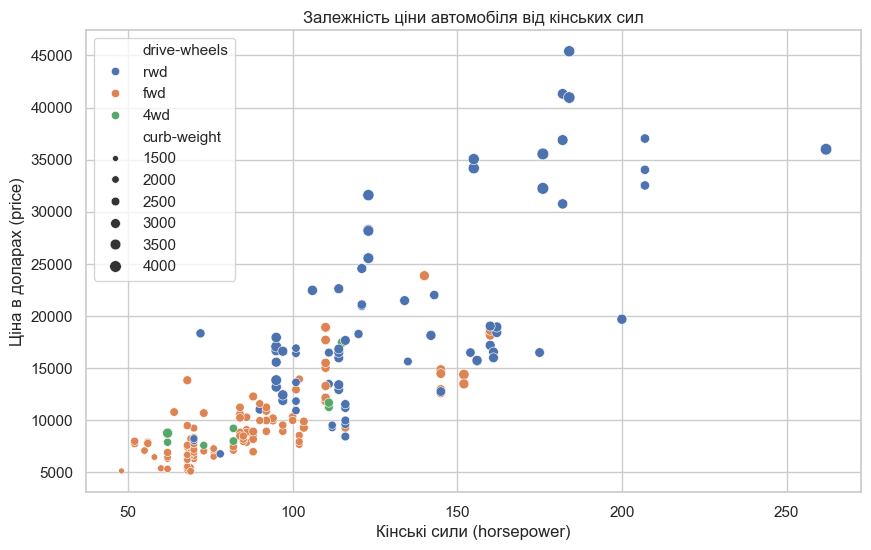

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='horsepower', y='price', hue='drive-wheels', size='curb-weight')
plt.title("Залежність ціни автомобіля від кінських сил")
plt.xlabel("Кінські сили (horsepower)")
plt.ylabel("Ціна в доларах (price)")

plt.show()

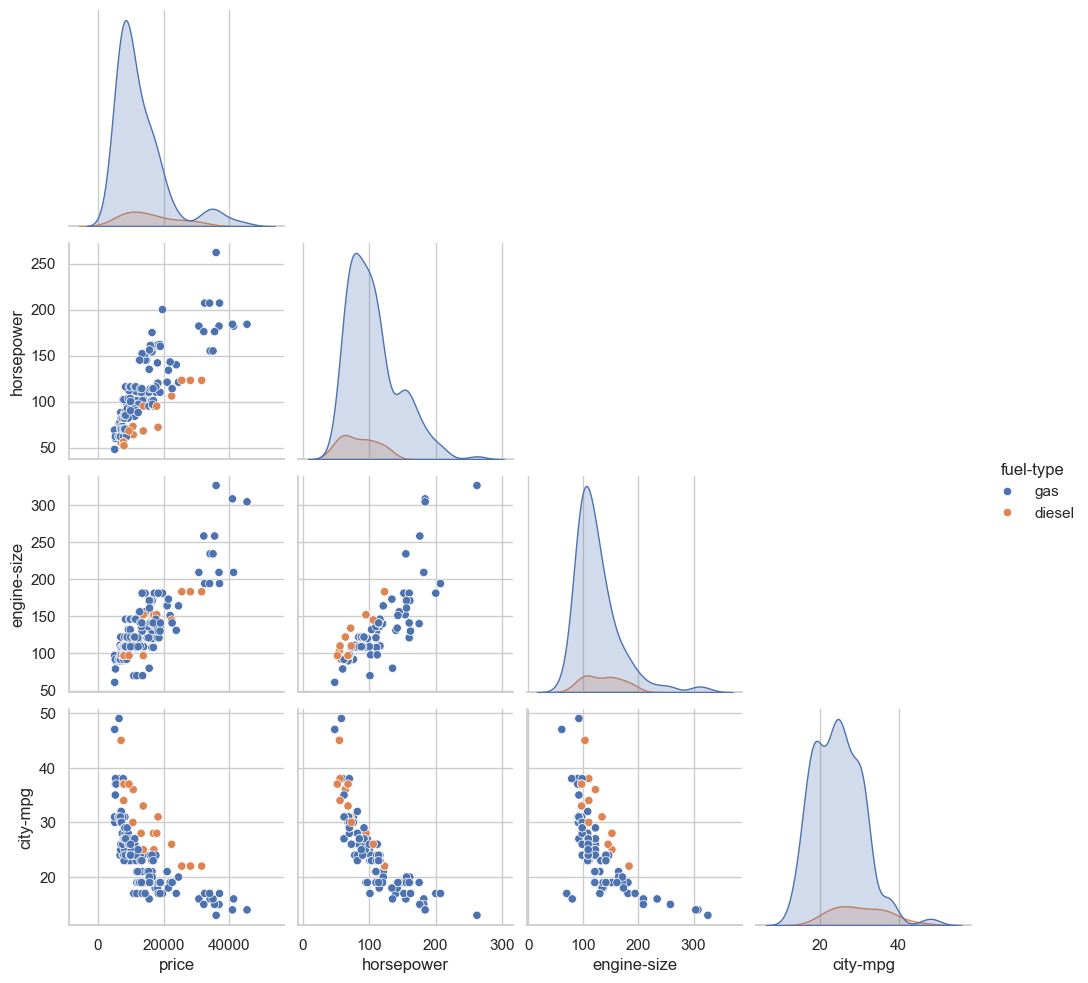

In [28]:
cols_for_pairplot = ['price', 'horsepower', 'engine-size', 'city-mpg', 'fuel-type']

sns.pairplot(df[cols_for_pairplot], hue='fuel-type', corner=True)

plt.show()

## Завдання 5: Додаткові візуалізації
Побудувати інші графіки, що покажуть корисну інформацію про датасет (щоб загальна кількість графіків становила 5-8).

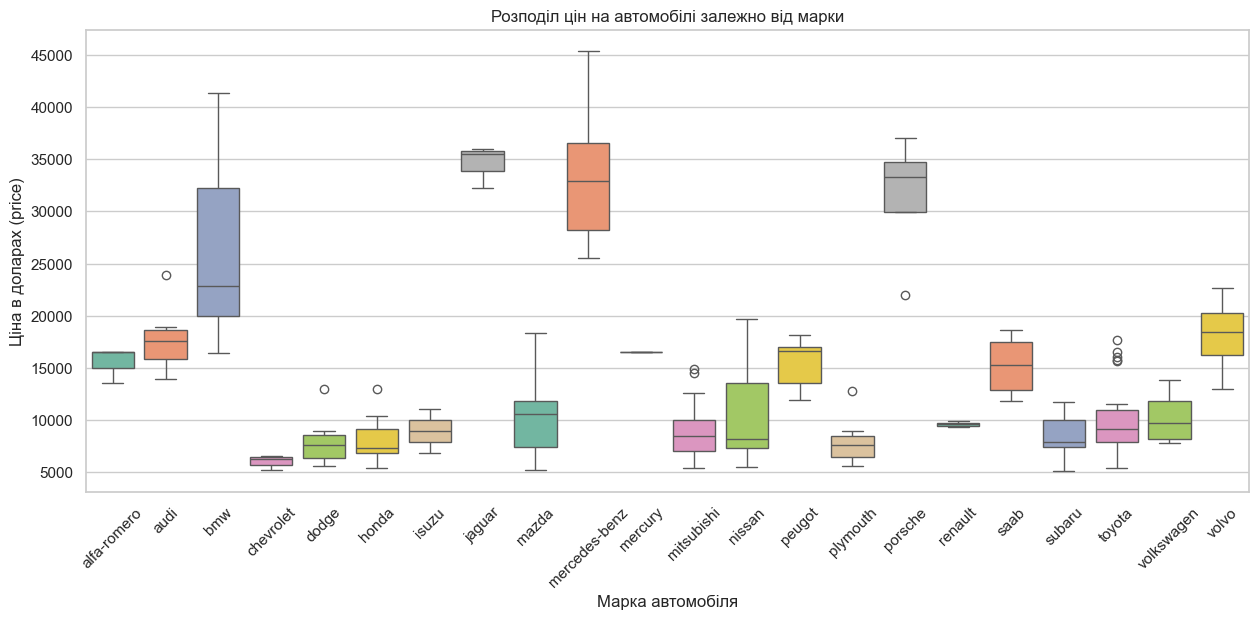

In [29]:
plt.figure(figsize=(15, 6))

sns.boxplot(data=df, x='make', y='price', hue='make', palette='Set2', legend=False)

plt.title("Розподіл цін на автомобілі залежно від марки")
plt.xlabel("Марка автомобіля")
plt.ylabel("Ціна в доларах (price)")

plt.xticks(rotation=45)

plt.show()

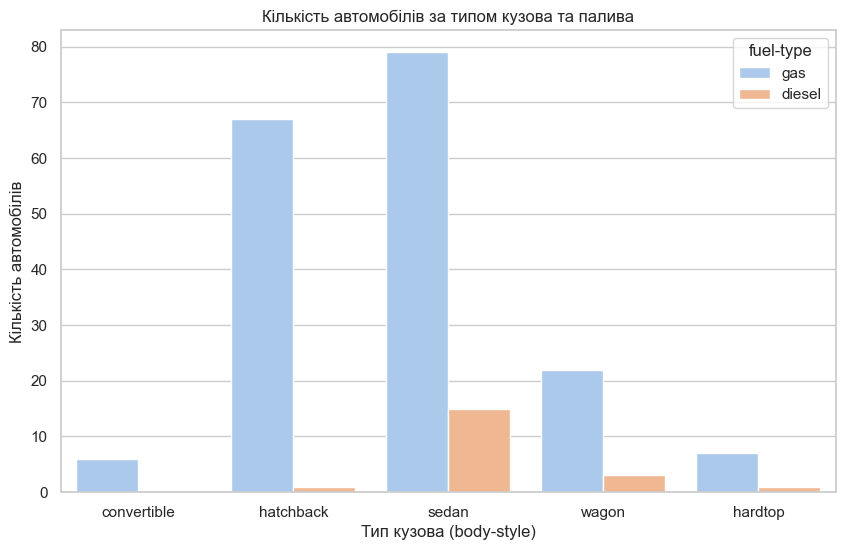

In [30]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='body-style', hue='fuel-type', palette='pastel')

plt.title("Кількість автомобілів за типом кузова та палива")
plt.xlabel("Тип кузова (body-style)")
plt.ylabel("Кількість автомобілів")

plt.show()